<a href="https://colab.research.google.com/github/devinaalifia0-alt/Visi-Komputer/blob/main/deteksi_tepi_batik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
!pip install opencv-python matplotlib scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from google.colab import files

(np.float64(-0.5), np.float64(625.5), np.float64(625.5), np.float64(-0.5))

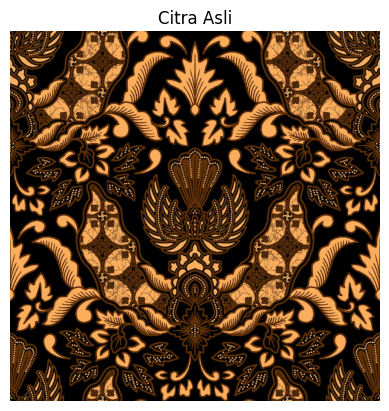

In [42]:
import cv2
import matplotlib.pyplot as plt

image_path = 'batik.jpg'

img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis('off')

(np.float64(-0.5), np.float64(209.5), np.float64(159.5), np.float64(-0.5))

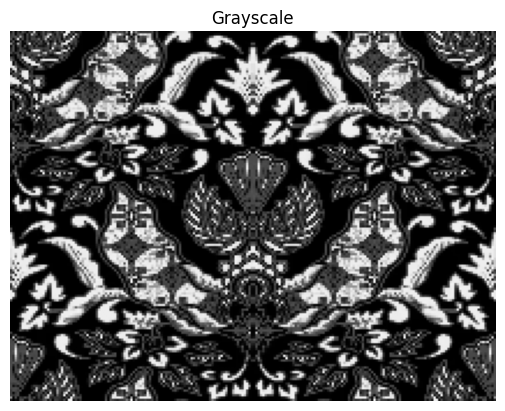

In [43]:
# Resize
img_resized = cv2.resize(img, (210, 160))

# Grayscale
gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

In [44]:
start = time.time()

kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
kernely = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])

prewitt_x = cv2.filter2D(gray, -1, kernelx)
prewitt_y = cv2.filter2D(gray, -1, kernely)
prewitt = np.sqrt(prewitt_x**2 + prewitt_y**2)

prewitt_time = time.time() - start

In [45]:
start = time.time()

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.sqrt(sobelx**2 + sobely**2)

sobel_time = time.time() - start

In [46]:
start = time.time()

canny = cv2.Canny(gray, 100, 200)

canny_time = time.time() - start

In [47]:
start = time.time()

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
dilation = cv2.dilate(gray, kernel)
erosion = cv2.erode(gray, kernel)
morph_grad = dilation - erosion

morph_time = time.time() - start

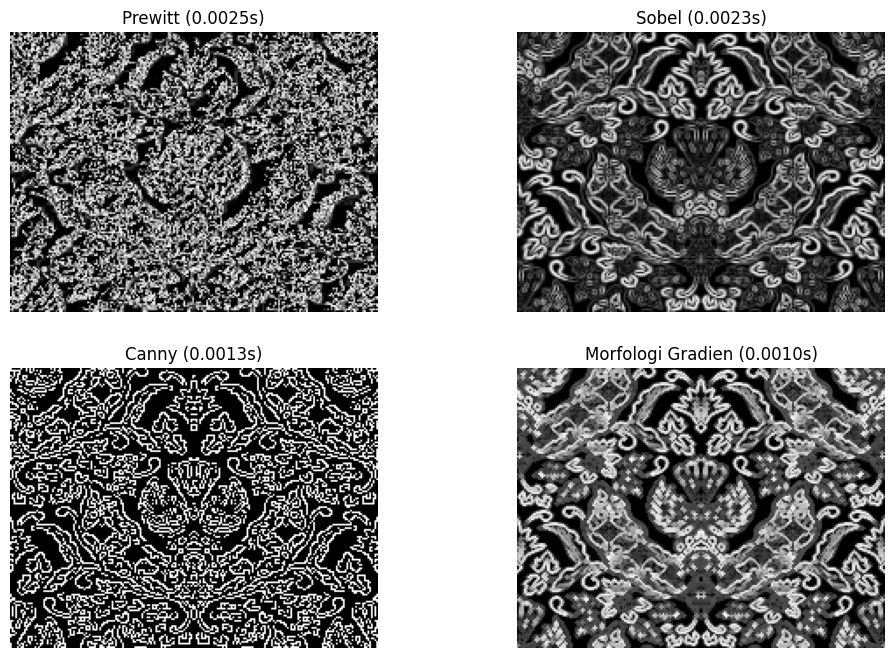

In [48]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(prewitt, cmap='gray')
plt.title(f"Prewitt ({prewitt_time:.4f}s)")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(sobel, cmap='gray')
plt.title(f"Sobel ({sobel_time:.4f}s)")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(canny, cmap='gray')
plt.title(f"Canny ({canny_time:.4f}s)")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(morph_grad, cmap='gray')
plt.title(f"Morfologi Gradien ({morph_time:.4f}s)")
plt.axis('off')

plt.show()

In [49]:
print("Waktu Proses:")
print(f"Prewitt            : {prewitt_time:.4f} detik")
print(f"Sobel              : {sobel_time:.4f} detik")
print(f"Canny              : {canny_time:.4f} detik")
print(f"Morfologi Gradien  : {morph_time:.4f} detik")

Waktu Proses:
Prewitt            : 0.0025 detik
Sobel              : 0.0023 detik
Canny              : 0.0013 detik
Morfologi Gradien  : 0.0010 detik
